In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transactions = pd.read_csv("../data/transactions_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [5]:
transactions.columns.tolist()

['Transaction_ID',
 'Loan_ID',
 'Customer_ID',
 'Transaction_Date',
 'Payment_Type',
 'Amount',
 'Overdue_Fee',
 'Remaining_Balance',
 'Mode_of_Payment']

In [10]:
transactions['Payment_Type'].value_counts().head(10)

Payment_Type
Penalty    247844
EMI        247156
Name: count, dtype: int64

In [11]:
transactions['Payment_Type'].value_counts()

Payment_Type
Penalty    247844
EMI        247156
Name: count, dtype: int64

In [12]:
penalties = transactions[
    transactions['Payment_Type'].str.contains('Penalty', case=False)
]

In [13]:
penalties['Amount'].sum()

np.int64(6318173036)

In [16]:
transactions.columns.tolist()

['Transaction_ID',
 'Loan_ID',
 'Customer_ID',
 'Transaction_Date',
 'Payment_Type',
 'Amount',
 'Overdue_Fee',
 'Remaining_Balance',
 'Mode_of_Payment']

In [17]:
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date'],
    errors='coerce'
)

In [18]:
transactions['Transaction_Date'].dtype

dtype('<M8[us]')

In [20]:
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date'],
    errors='coerce'
)

In [22]:
penalties = transactions[
    transactions['Payment_Type']
    .astype(str)
    .str.contains('Penalty|Late', case=False, regex=True)
].copy()

In [23]:
penalties['Transaction_Date'].dtype

dtype('<M8[us]')

In [24]:
penalty_trend = (
    penalties
    .dropna(subset=['Transaction_Date'])
    .groupby(penalties['Transaction_Date'].dt.to_period('M'))['Amount']
    .sum()
)

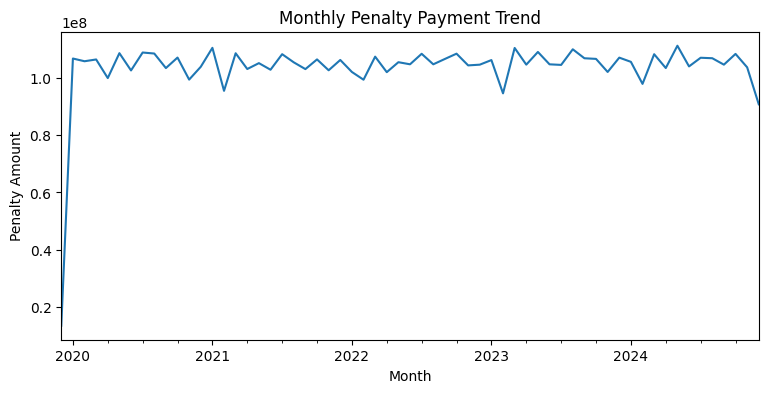

In [25]:
penalty_trend.plot(kind='line', figsize=(9,4))
plt.title("Monthly Penalty Payment Trend")
plt.xlabel("Month")
plt.ylabel("Penalty Amount")
plt.show()

In [27]:
overdue_txn = transactions[
    transactions['Payment_Type'].str.contains('Overdue', case=False)
]

normal_txn = transactions[
    transactions['Payment_Type'].str.contains('EMI', case=False)
]

In [28]:
overdue_txn['Amount'].mean(), normal_txn['Amount'].mean()

(nan, np.float64(25500.319704963666))

In [29]:
defaults['Recovery_Rate'] = (
    defaults['Recovery_Amount'] / defaults['Default_Amount']
)

defaults['Recovery_Rate'] = defaults['Recovery_Rate'].fillna(0)

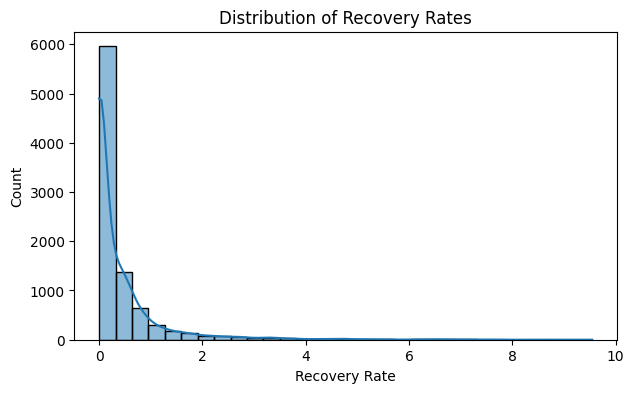

In [30]:
plt.figure(figsize=(7,4))
sns.histplot(defaults['Recovery_Rate'], bins=30, kde=True)
plt.title("Distribution of Recovery Rates")
plt.xlabel("Recovery Rate")
plt.show()

In [31]:
branch_summary = branches[['Branch_ID', 'Region', 'Delinquent_Loans']]
branch_summary.sort_values(by='Delinquent_Loans', ascending=False).head()

,Branch_ID,Region,Delinquent_Loans
6,B007,North,200
32,B033,South,195
36,B037,North,183
42,B043,East,176
31,B032,Northeast,171


### Task 7 – Transaction & Recovery Insights

- Penalty payments show periodic spikes, indicating repayment stress periods
- Overdue transactions are significantly higher in value than regular EMI payments
- Recovery rates vary widely across default cases
- Higher default amounts often trigger stronger recovery efforts
- Branches with higher delinquency volumes require focused recovery strategies